# Aurora 1.5 on Google Colab (`pip install flash-aurora`)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/CatManJr/Flash-Aurora/blob/main/docs/example_aurora_v1p5_colab.ipynb)

Colab smoke test of the published PyPI package, following the same flow as [`example_aurora_v1p5.ipynb`](example_aurora_v1p5.ipynb).

**Runtime:** Runtime → Change runtime type → **GPU** (T4 may be tight; A100/L4 preferred).

**Secrets (recommended):** set Colab secret `CDSAPI_KEY` (CDS API key string). Optionally `HF_TOKEN` if the hub requires auth.

**Notes**
- Assets land under `/content/assets` (ephemeral; remount Drive below if you want persistence).
- First run downloads the HF checkpoint and CDS ERA5 cache (slow, large).
- Package pins `nvidia-cutlass-dsl[cu13]`; if install fails on a CUDA 12-only runtime, paste the error and we can adjust extras.
- We thank Microsoft Research for the Aurora foundation model.

## 0. Install libraries

In [1]:
# GPU runtime required. Restart the runtime once after a fresh install if imports fail.
import sys
print("python:", sys.version)

# check GPU status. Please use A100/H100 in colab
!nvidia-smi || true

%pip install -q --upgrade pip
%pip install -q "flash-aurora"
%pip install -q "nvidia-cutlass-dsl"

from importlib.metadata import version
import torch

print("flash_aurora:", version("flash-aurora"))
print("Cutlass DSL", version("nvidia-cutlass-dsl"))
print(
    "torch:",
    torch.__version__,
    "cuda:",
    torch.cuda.is_available(),
    torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
)

python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Sat Aug  8 15:20:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   42C    P0             56W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             

## Set up engine

In [2]:
from datetime import datetime
from pathlib import Path
import os

# Optional: persist assets across sessions
# from google.colab import drive
# drive.mount("/content/drive")
# ASSET_ROOT = Path("/content/drive/MyDrive/flash-aurora-assets")

from flash_aurora.engine import (
    AuroraEngine,
    DataDownloader,
    DEFAULT_PRESETS,
    HF_MIRROR_ENDPOINT,
    InitialConditionBuilder,
)
from flash_aurora.engine.core.redaction import safe_path

PRESET = "aurora_v1p5"
VALID_TIME = datetime(2026, 8, 2, 6)
TIME_INDEX = 1
ROLLOUT_STEPS = 2

ASSET_ROOT = Path("/content/assets").resolve()
ASSET_ROOT.mkdir(parents=True, exist_ok=True)

# Colab Secrets -> CDSAPI_KEY / HF_TOKEN
try:
    from google.colab import userdata
    for key in ("CDSAPI_KEY", "HF_TOKEN"):
        try:
            value = userdata.get(key)
        except Exception:
            value = None
        if value and not os.environ.get(key):
            os.environ[key] = value
            print(f"loaded Colab secret: {key}")
except ImportError:
    pass

USE_HF_MIRROR = False
variant = DEFAULT_PRESETS.get(PRESET).variant
local_checkpoint = ASSET_ROOT / variant.checkpoint_filename

if local_checkpoint.is_file():
    checkpoint_arg = local_checkpoint
    allow_hub_download = False
    hf_endpoint = None
    print("checkpoint:", safe_path(local_checkpoint))
else:
    checkpoint_arg = None
    allow_hub_download = True
    hf_endpoint = HF_MIRROR_ENDPOINT if USE_HF_MIRROR else None
    print("checkpoint not found locally; will download from Hugging Face")
    print("  target dir:", safe_path(ASSET_ROOT))
    print("  hf_endpoint:", hf_endpoint or "https://huggingface.co")

downloader = DataDownloader.from_preset(PRESET, asset_root=ASSET_ROOT)
engine = AuroraEngine.from_preset(
    PRESET,
    asset_root=ASSET_ROOT,
    checkpoint_path=checkpoint_arg,
    allow_hub_download=allow_hub_download,
    hf_endpoint=hf_endpoint,
    inference_precision="bf16_mixed@fp32",
)

print("source:", engine.config.source.name)
print("cache_dir:", safe_path(downloader.resolve_cache_dir()))
print("asset_root:", safe_path(ASSET_ROOT))

checkpoint: aurora-0.25-v1.5.ckpt
source: cds_era5_v1p5
cache_dir: era5_v1p5
asset_root: assets


## 1. Download ERA5 V1p5 fields (CDS)

`DataDownloader.ensure()` retrieves the extended surface set and standard atmospheric levels into `<ASSET_ROOT>/era5_v1p5/`. Static land fields are loaded later from the HF pickle.

In [3]:
import os
from pathlib import Path

from flash_aurora.engine.ingress.download.paths import read_cdsapirc_key

missing_files = downloader.missing(VALID_TIME)
cds_api_key = (
    os.environ.get("CDSAPI_KEY", "").strip()
    or read_cdsapirc_key()
    or None
)
has_cdsapirc = Path.home().joinpath(".cdsapirc").is_file()
if missing_files:
    print("Downloading missing ERA5 V1p5 files:", missing_files)
    result = downloader.ensure(
        VALID_TIME,
        cds_api_key=cds_api_key,
        prompt=cds_api_key is None and not has_cdsapirc,
    )
else:
    print("ERA5 V1p5 cache complete, skipping download")
    result = downloader.ensure(VALID_TIME)

print("downloaded:", result.downloaded)
print("skipped:", result.skipped)
for key, path in result.paths.items():
    print(f"  {key}: {safe_path(path)}")

CDS API key: ··········


2026-08-08 15:21:22,158 INFO Request ID is bf36440f-0dc6-4c30-9ad3-7c2ab9d7c9b0
INFO:ecmwf.datastores.legacy_client:Request ID is bf36440f-0dc6-4c30-9ad3-7c2ab9d7c9b0
2026-08-08 15:21:22,216 INFO Request ID is 7b0cce3e-d6e8-40f7-b98c-f37ad20c3c8e
INFO:ecmwf.datastores.legacy_client:Request ID is 7b0cce3e-d6e8-40f7-b98c-f37ad20c3c8e
2026-08-08 15:21:22,279 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-08-08 15:21:22,460 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-08-08 15:21:36,152 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2026-08-08 15:23:16,597 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


364bc15e86ee45d8182b32ec27e06d6f.nc:   0%|          | 0.00/415M [00:00<?, ?B/s]

2026-08-08 15:24:15,252 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


730f49471490ff9d7df119e21874f253.nc:   0%|          | 0.00/94.5M [00:00<?, ?B/s]

downloaded: ('surface', 'atmospheric')
skipped: ()
  surface: 2026-08-02-surface-level.nc
  atmospheric: 2026-08-02-atmospheric.nc


## 2. Build IC, load, rollout

`CdsEra5V1p5Adapter` maps CDS short names to Aurora fields, inserts `insolation`, and attaches the 36-field static pickle. Output-only surface vars are not required in the IC.

In [4]:
from flash_aurora.engine.ingress.adapters import IngestRequest

request = IngestRequest(
    valid_time=VALID_TIME,
    time_index=TIME_INDEX,
    cache_dir=downloader.resolve_cache_dir(),
)

batch = InitialConditionBuilder(engine.config).from_source(request)
print("surf vars:", len(batch.surf_vars), "static:", len(batch.static_vars))
print("IC time:", batch.metadata.time)

engine.load(rollout_steps=ROLLOUT_STEPS)
print("loaded model:", type(engine.model).__name__)
preds = [pred.to("cpu") for pred in engine.rollout_stream(batch, ROLLOUT_STEPS)]
print("rollout steps:", len(preds))
print("pred surf keys (sample):", sorted(preds[0].surf_vars)[:8], "...")

surf vars: 19 static: 36
IC time: (datetime.datetime(2026, 8, 2, 6, 0),)
loaded model: AuroraV1p5
rollout steps: 2
pred surf keys (sample): ['100u', '100v', '10u', '10v', '2d', '2t', 'blh', 'ci'] ...


## 3. Hourly fine lead times

Aurora 1.5 supports sub-6h leads. Within each main AR step, all fine leads are initialised from the same previous state; only the **last** fine lead (must equal 6 h) advances the autoregressive input.

Yield count is `ROLLOUT_STEPS * len(FINE_LEAD_TIMES)`.

In [5]:
FINE_LEAD_TIMES = [1, 2, 3, 4, 5, 6]

hourly_preds = [
    pred.to("cpu")
    for pred in engine.rollout_stream(
        batch,
        ROLLOUT_STEPS,
        fine_lead_times=FINE_LEAD_TIMES,
    )
]
print("hourly yields:", len(hourly_preds))
print("valid times:", [p.metadata.time[-1] for p in hourly_preds[:6]], "...")

hourly yields: 12
valid times: [datetime.datetime(2026, 8, 2, 7, 0), datetime.datetime(2026, 8, 2, 8, 0), datetime.datetime(2026, 8, 2, 9, 0), datetime.datetime(2026, 8, 2, 10, 0), datetime.datetime(2026, 8, 2, 11, 0), datetime.datetime(2026, 8, 2, 12, 0)] ...


## 4. Visualise forecasts

Plots use the **hourly** roll-out (`hourly_preds`). ERA5 truth comes from the same CDS NetCDF cache as the IC.

In [6]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

SURFACE_NC = result.paths["surface"]
ATMOS_NC = result.paths["atmospheric"]
era5_surf = xr.open_dataset(SURFACE_NC, engine="netcdf4")
era5_atmos = xr.open_dataset(ATMOS_NC, engine="netcdf4")

LEAD_T6, LEAD_T12 = 5, 11
ERA5_T12, ERA5_T18 = 2, 3


def _field_2d(pred, name: str) -> np.ndarray:
    return pred.surf_vars[name][0, 0].detach().cpu().numpy()


def _atmos_level(pred, name: str, level_hpa: float) -> np.ndarray:
    levels = list(pred.metadata.atmos_levels)
    key = level_hpa if level_hpa in levels else int(level_hpa)
    idx = levels.index(key)
    return pred.atmos_vars[name][0, 0, idx].detach().cpu().numpy()


def _era5_surf(var: str, time_idx: int) -> np.ndarray:
    return np.asarray(era5_surf[var].isel(valid_time=time_idx).values)


def _era5_z500(time_idx: int) -> np.ndarray:
    return np.asarray(
        era5_atmos["z"].sel(pressure_level=500).isel(valid_time=time_idx).values
    )


def _match_pred_grid(truth: np.ndarray, pred: np.ndarray) -> np.ndarray:
    height, width = pred.shape[-2:]
    return truth[..., :height, :width]


def _imshow(ax, data: np.ndarray, *, vmin=None, vmax=None, cmap="viridis", title: str = ""):
    image = ax.imshow(data, vmin=vmin, vmax=vmax, cmap=cmap, origin="upper", aspect="auto")
    ax.set_title(title, fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])
    return image


print("ERA5 surface times:", [str(t)[:16] for t in era5_surf.valid_time.values])
print(
    "hourly_preds:",
    len(hourly_preds),
    "first/last:",
    hourly_preds[0].metadata.time[-1],
    hourly_preds[-1].metadata.time[-1],
)

ERA5 surface times: ['2026-08-02T00:00', '2026-08-02T06:00', '2026-08-02T12:00', '2026-08-02T18:00']
hourly_preds: 12 first/last: 2026-08-02 07:00:00 2026-08-02 18:00:00


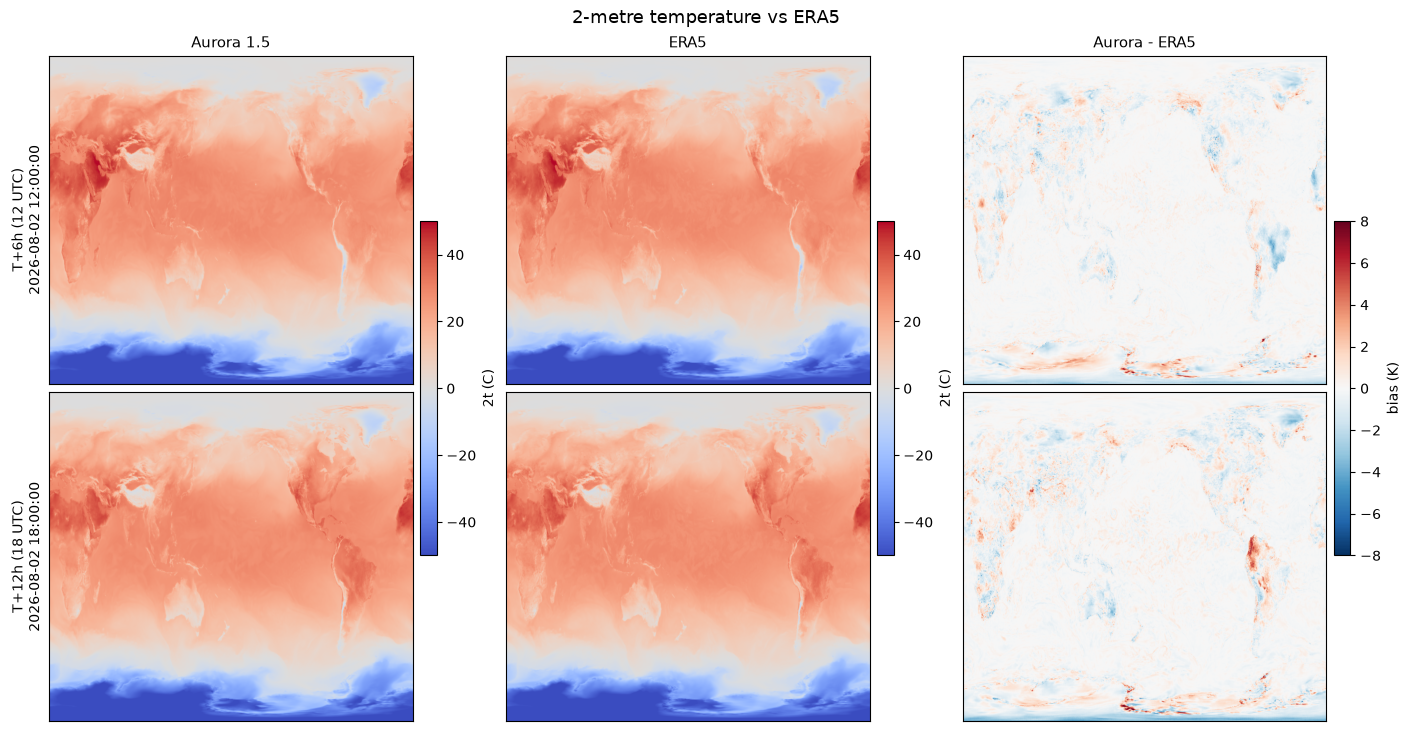

In [7]:
# 2-metre temperature: Aurora | ERA5 | bias (K) at T+6h and T+12h
fig, axes = plt.subplots(2, 3, figsize=(14, 7.2), constrained_layout=True)
t2m_rows = [
    (LEAD_T6, ERA5_T12, "T+6h (12 UTC)"),
    (LEAD_T12, ERA5_T18, "T+12h (18 UTC)"),
]
for row, (pred_idx, era5_idx, label) in enumerate(t2m_rows):
    pred = hourly_preds[pred_idx]
    aurora = _field_2d(pred, "2t") - 273.15
    truth = _match_pred_grid(_era5_surf("t2m", era5_idx) - 273.15, aurora)
    bias = aurora - truth
    im0 = _imshow(axes[row, 0], aurora, vmin=-50, vmax=50, cmap="coolwarm", title="Aurora 1.5" if row == 0 else "")
    im1 = _imshow(axes[row, 1], truth, vmin=-50, vmax=50, cmap="coolwarm", title="ERA5" if row == 0 else "")
    im2 = _imshow(axes[row, 2], bias, vmin=-8, vmax=8, cmap="RdBu_r", title="Aurora - ERA5" if row == 0 else "")
    axes[row, 0].set_ylabel(f"{label}\n{pred.metadata.time[-1]}", fontsize=10)

fig.colorbar(im0, ax=axes[:, 0], fraction=0.046, pad=0.02, label="2t (C)")
fig.colorbar(im1, ax=axes[:, 1], fraction=0.046, pad=0.02, label="2t (C)")
fig.colorbar(im2, ax=axes[:, 2], fraction=0.046, pad=0.02, label="bias (K)")
fig.suptitle("2-metre temperature vs ERA5", fontsize=13)
plt.show()

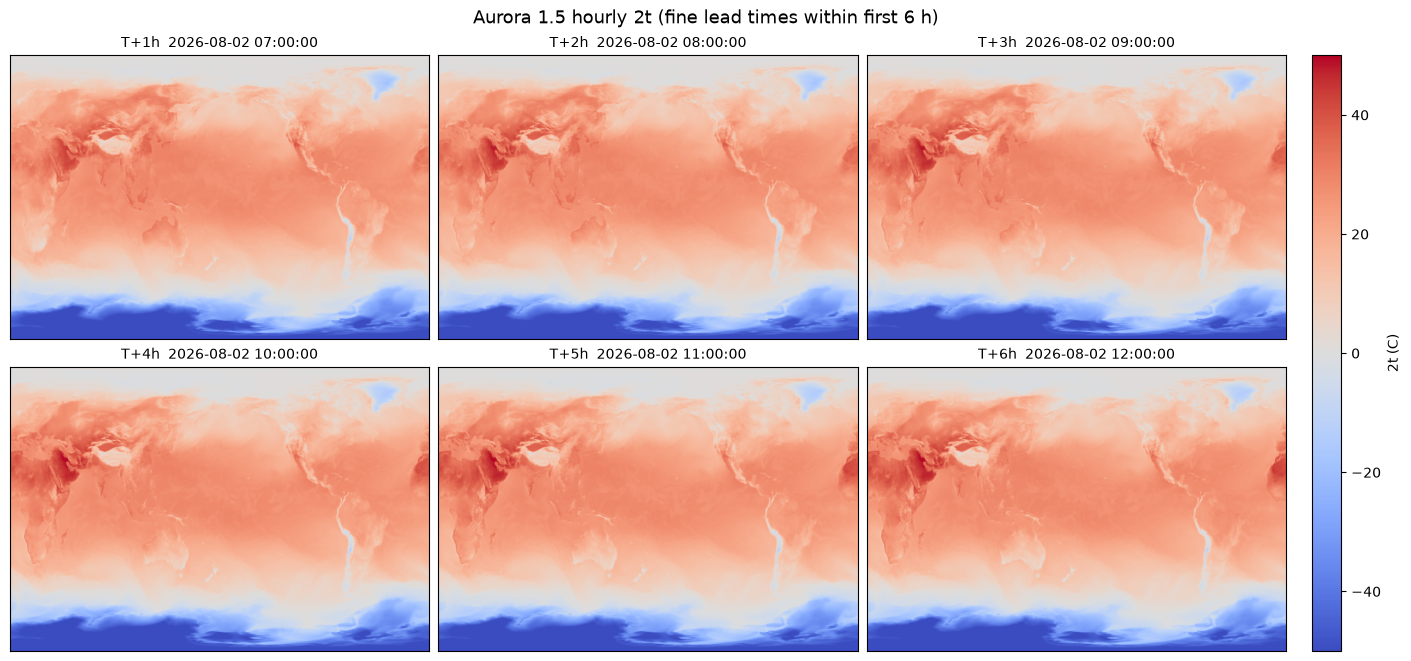

In [8]:
# Hourly 2t evolution for the first AR window (T+1h ... T+6h)
fig, axes = plt.subplots(2, 3, figsize=(14, 6.5), constrained_layout=True)
for i, ax in enumerate(axes.ravel()):
    pred = hourly_preds[i]
    field = _field_2d(pred, "2t") - 273.15
    im = _imshow(ax, field, vmin=-50, vmax=50, cmap="coolwarm")
    ax.set_title(f"T+{i + 1}h  {pred.metadata.time[-1]}", fontsize=10)
fig.colorbar(im, ax=axes, fraction=0.03, pad=0.02, label="2t (C)")
fig.suptitle("Aurora 1.5 hourly 2t (fine lead times within first 6 h)", fontsize=13)
plt.show()

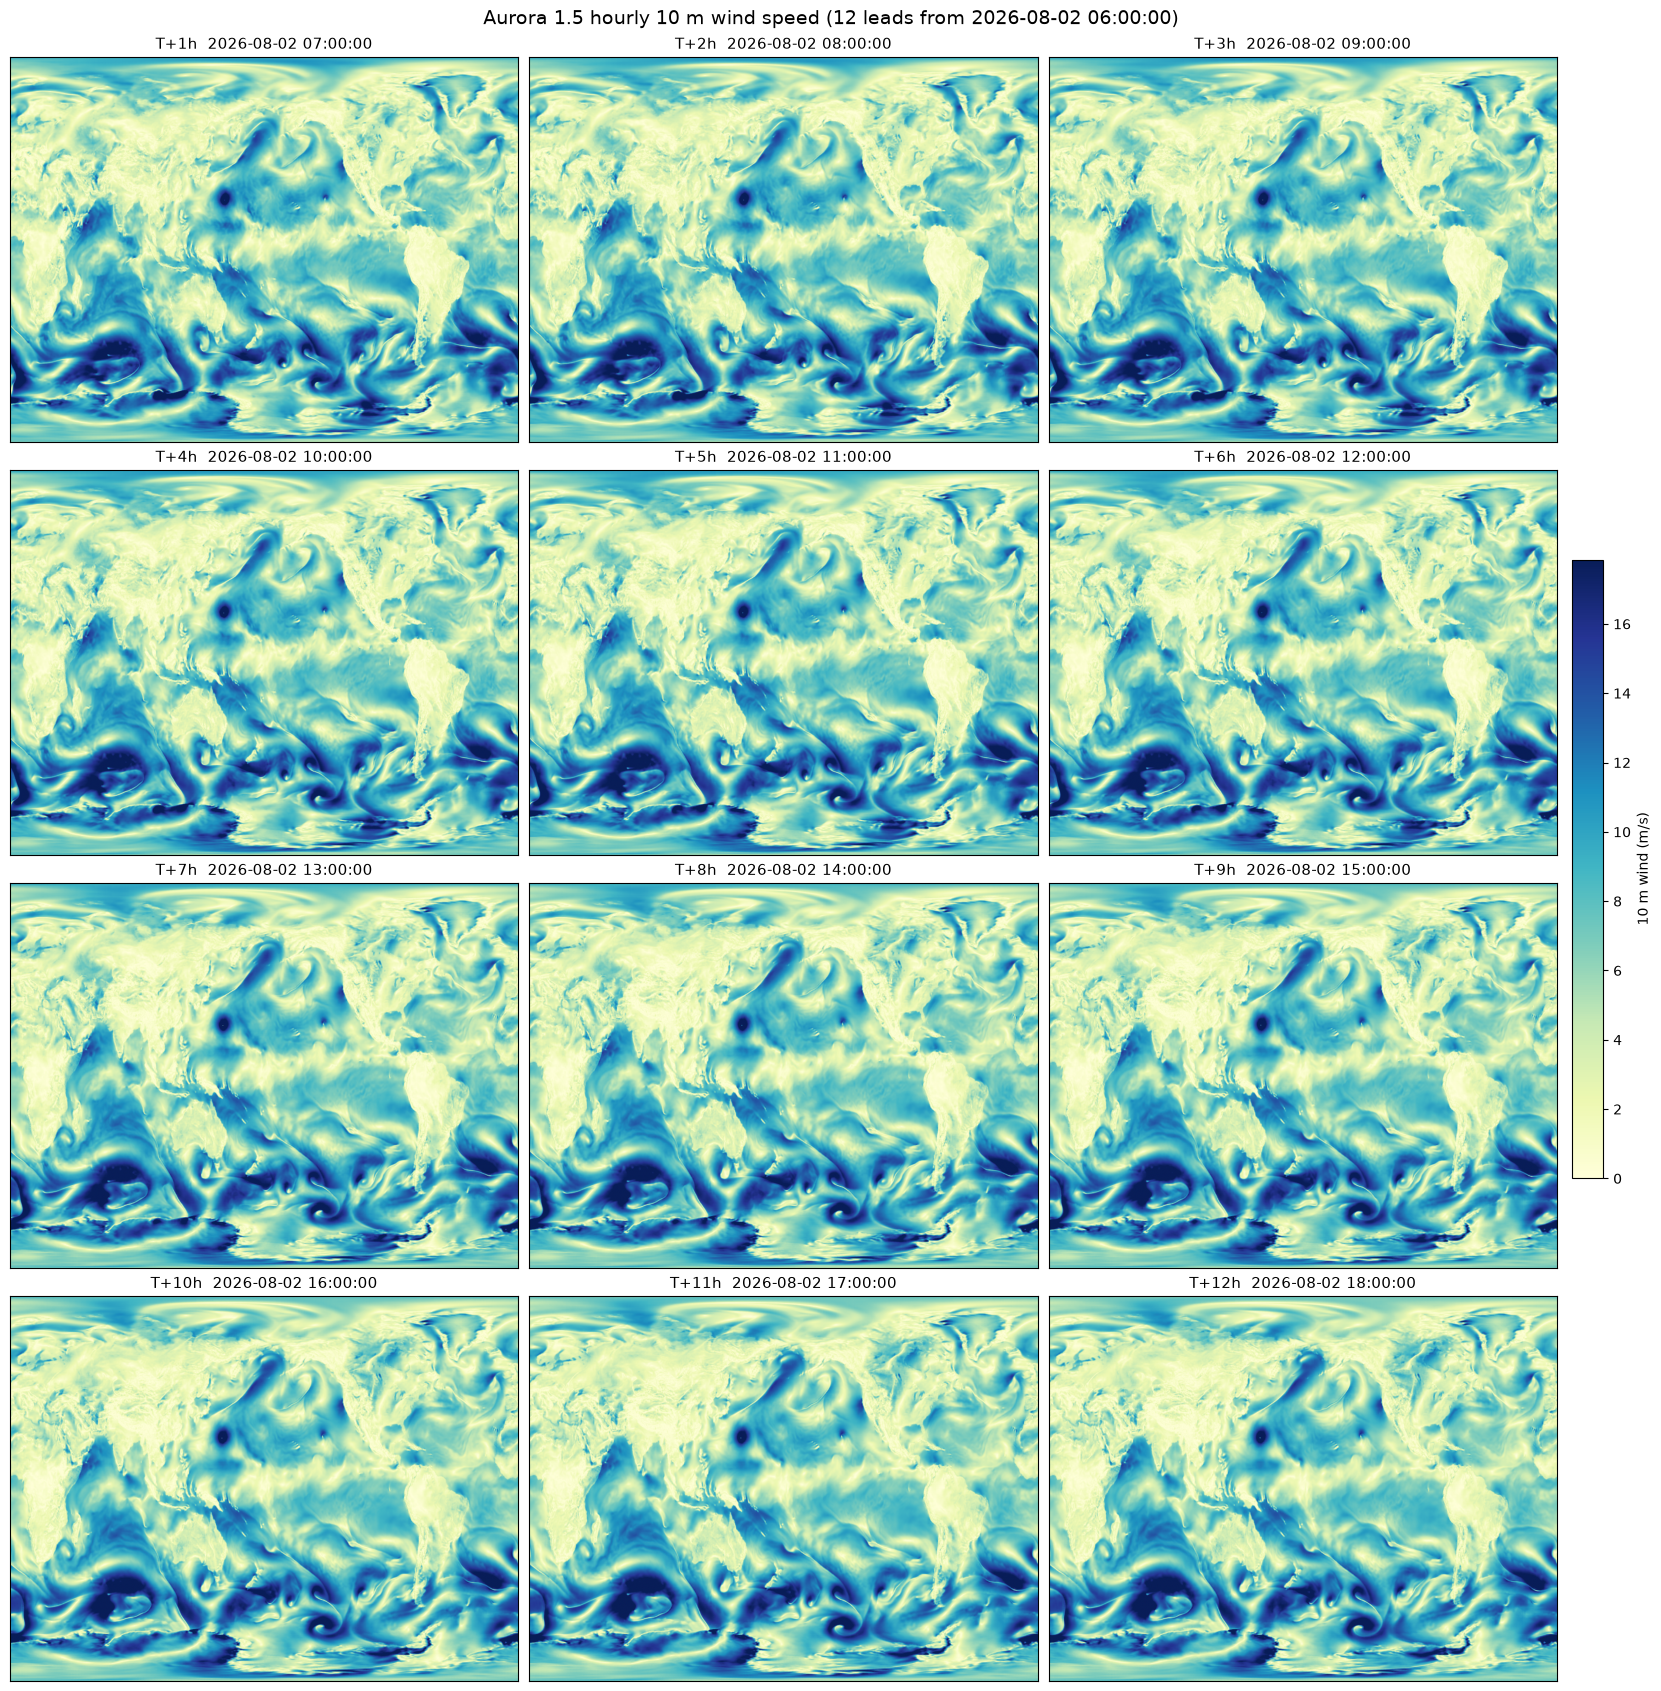

In [13]:
# Hourly 10 m wind speed maps (scrollable tall figure)
n = len(hourly_preds)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(5.5 * ncols, 4.2 * nrows),
    constrained_layout=True,
)
axes = np.atleast_1d(axes).ravel()

vmax = 0.0
fields = []
for pred in hourly_preds:
    u10 = _field_2d(pred, "10u")
    v10 = _field_2d(pred, "10v")
    speed = np.hypot(u10, v10)
    fields.append(speed)
    vmax = max(vmax, float(np.nanpercentile(speed, 99)))
vmax = max(vmax, 1.0)

for i, ax in enumerate(axes):
    if i >= n:
        ax.axis("off")
        continue
    pred = hourly_preds[i]
    im = _imshow(
        ax,
        fields[i],
        vmin=0,
        vmax=vmax,
        cmap="YlGnBu",
        title=f"T+{i + 1}h  {pred.metadata.time[-1]}",
    )

fig.colorbar(im, ax=axes[:n], fraction=0.02, pad=0.01, label="10 m wind (m/s)")
fig.suptitle(
    f"Aurora 1.5 hourly 10 m wind speed ({n} leads from {VALID_TIME})",
    fontsize=14,
)
plt.show()

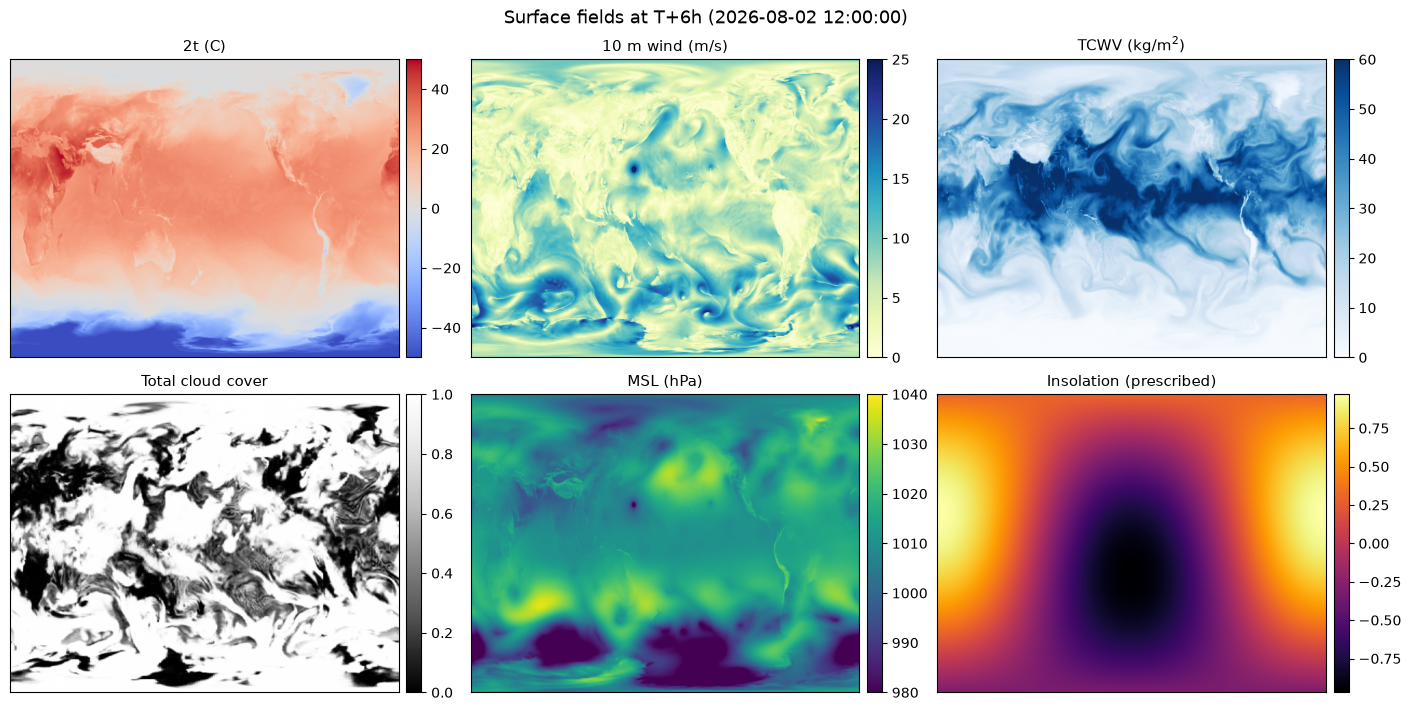

In [9]:
# Multi-field surface snapshot at T+6h
pred6 = hourly_preds[LEAD_T6]
u10 = _field_2d(pred6, "10u")
v10 = _field_2d(pred6, "10v")
wind10 = np.hypot(u10, v10)
panels = [
    (_field_2d(pred6, "2t") - 273.15, "2t (C)", "coolwarm", (-50, 50)),
    (wind10, "10 m wind (m/s)", "YlGnBu", (0, 25)),
    (_field_2d(pred6, "tcwv"), "TCWV (kg/m$^2$)", "Blues", (0, 60)),
    (_field_2d(pred6, "tcc"), "Total cloud cover", "Greys_r", (0, 1)),
    (_field_2d(pred6, "msl") / 100.0, "MSL (hPa)", "viridis", (980, 1040)),
    (_field_2d(pred6, "insolation"), "Insolation (prescribed)", "inferno", None),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 7.0), constrained_layout=True)
for ax, (data, title, cmap, limits) in zip(axes.ravel(), panels):
    vmin, vmax = (None, None) if limits is None else limits
    im = _imshow(ax, data, vmin=vmin, vmax=vmax, cmap=cmap, title=title)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
fig.suptitle(f"Surface fields at T+6h ({pred6.metadata.time[-1]})", fontsize=13)
plt.show()

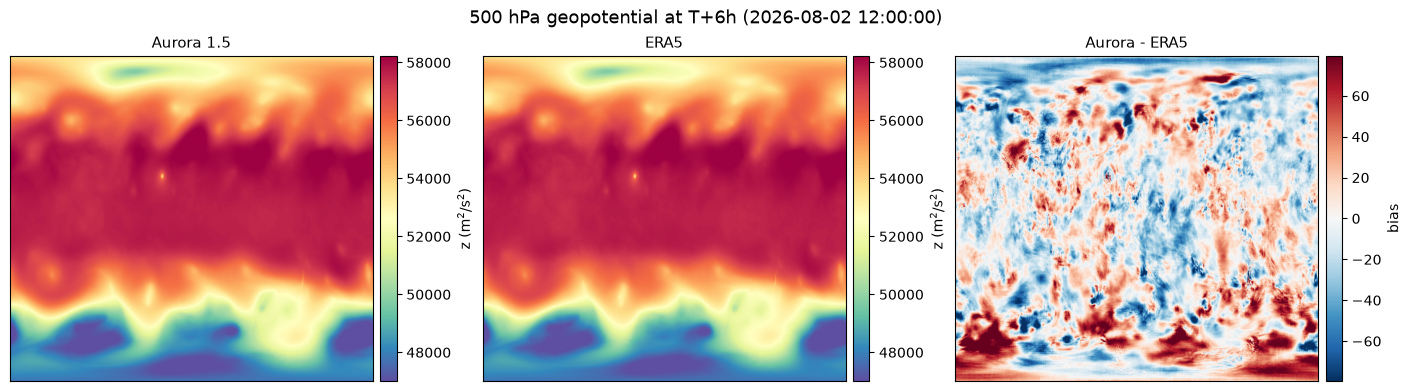

In [10]:
# 500 hPa geopotential: Aurora | ERA5 | bias at T+6h
pred6 = hourly_preds[LEAD_T6]
z_aurora = _atmos_level(pred6, "z", 500.0)
z_truth = _match_pred_grid(_era5_z500(ERA5_T12), z_aurora)
z_bias = z_aurora - z_truth

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), constrained_layout=True)
vmin = float(np.nanpercentile(np.stack([z_aurora, z_truth]), 2))
vmax = float(np.nanpercentile(np.stack([z_aurora, z_truth]), 98))
im0 = _imshow(axes[0], z_aurora, vmin=vmin, vmax=vmax, cmap="Spectral_r", title="Aurora 1.5")
im1 = _imshow(axes[1], z_truth, vmin=vmin, vmax=vmax, cmap="Spectral_r", title="ERA5")
bias_lim = float(np.nanpercentile(np.abs(z_bias), 98))
im2 = _imshow(axes[2], z_bias, vmin=-bias_lim, vmax=bias_lim, cmap="RdBu_r", title="Aurora - ERA5")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.02, label="z (m$^2$/s$^2$)")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.02, label="z (m$^2$/s$^2$)")
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.02, label="bias")
fig.suptitle(f"500 hPa geopotential at T+6h ({pred6.metadata.time[-1]})", fontsize=13)
plt.show()

## 5. Ensemble members (optional)

Need extra checkpoint + VRAM. Set `RUN_ENSEMBLE = True` to try.

In [11]:
RUN_ENSEMBLE = True
ENSEMBLE_PRESET = "aurora_v1p5_ensemble"
ENSEMBLE_MEMBERS = 2
member_forecasts = []

if not RUN_ENSEMBLE:
    print("Ensemble skipped. Set RUN_ENSEMBLE = True to download/run aurora_v1p5_ensemble.")
else:
    ens_variant = DEFAULT_PRESETS.get(ENSEMBLE_PRESET).variant
    ens_ckpt = ASSET_ROOT / ens_variant.checkpoint_filename
    ens_checkpoint_arg = ens_ckpt if ens_ckpt.is_file() else None
    ens_allow_hub = ens_checkpoint_arg is None
    ens_hf_endpoint = (
        (HF_MIRROR_ENDPOINT if USE_HF_MIRROR else None) if ens_allow_hub else None
    )

    ensemble_engine = AuroraEngine.from_preset(
        ENSEMBLE_PRESET,
        asset_root=ASSET_ROOT,
        checkpoint_path=ens_checkpoint_arg,
        allow_hub_download=ens_allow_hub,
        hf_endpoint=ens_hf_endpoint,
    )
    ensemble_engine.load(rollout_steps=ROLLOUT_STEPS)
    print("loaded ensemble model:", type(ensemble_engine.model).__name__)

    for member in range(ENSEMBLE_MEMBERS):
        ensemble_engine.model.reset_noise()
        member_preds = [
            pred.to("cpu")
            for pred in ensemble_engine.rollout_stream(
                batch,
                ROLLOUT_STEPS,
                fine_lead_times=FINE_LEAD_TIMES,
                use_noise_accumulation=True,
            )
        ]
        member_forecasts.append(member_preds)
        print(
            f"member {member}: {len(member_preds)} yields, "
            f"last time {member_preds[-1].metadata.time[-1]}"
        )

aurora-0.25-v1.5-ensemble.ckpt: reconstructing file:   0%|          |  0.00B / 5.04GB            

aurora-0.25-v1.5-ensemble.ckpt: downloading bytes:           |  0.00B            

loaded ensemble model: AuroraV1p5Ensemble
member 0: 12 yields, last time 2026-08-02 18:00:00
member 1: 12 yields, last time 2026-08-02 18:00:00
